In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.common import kb_eV, T, kb_J, h 
from _CO_Oxidation import wrapper_acid as wp
from _CO_Oxidation.wrapper_acid import plot_posteriors, plot_model_fits, plot_coverages, plot_drc

C_H_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Pt66Ru33_HClO4.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_H_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_H_in = wp.C_H_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    rate_model = pt.exp(log_rate)
    sigma_rel = pm.Gamma('sigma_rel', alpha=2, beta=20)
    sigma_base = pm.HalfNormal('sigma_base', sigma=1e-2)
    exponent =  pm.HalfNormal('exponent', sigma=1)
    sigma_model = pt.sqrt(sigma_base**2 + (sigma_rel**2)*(rate_model ** exponent))
    # sigma_total = pt.sqrt(wp.rate_SD_obs**2 + sigma_model**2)
    rate = pm.StudentT('rate', nu=2, mu=rate_model, sigma=sigma_model, observed=wp.rate_obs_matrix)
    return rate

Ru_comp = 0.33

# LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,20,0,0.01,7
,20,0,0.01,3
,20,0,0.02,3
,20,0,0.08,3


Computed from 40 posterior samples and 748 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -24349.06    34.85
p_loo    22606.29        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.38]   (good)        0    0.0%
   (0.38, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)  748  100.0%



c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.38 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


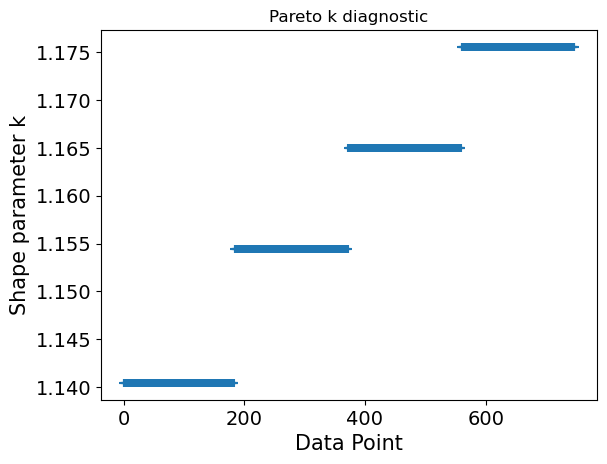

In [4]:
with pm.Model() as LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=0.0, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE
    delta = pm.Normal('delta', mu=0.0, sigma=0.2) # symmetry factor for RDS

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = pt.logaddexp(log_k2 + np.log(C_H_in), np.log(kb_J*T/h) - delta/(kb_eV*T))
    rate = observables(log_rate) 

trace_LH_2, loo_LH_2 = fit_and_evaluate(LH_2, draws=10, tune=10)

             mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.143   0.167  -0.356    0.098      0.047    0.016      12.0      28.0   1.89
deltaG4_0   0.141   0.530  -0.574    0.869      0.164    0.072      11.0      20.0   2.39
Gact2_0     0.455   0.382   0.101    1.021      0.121    0.047      11.0      20.0   3.40
delta       0.646   0.139   0.541    0.907      0.043    0.026      11.0      20.0   3.34
sigma_rel   8.953  14.039   0.045   34.947      4.424    2.532      11.0      20.0   4.04
sigma_base  0.005   0.004   0.000    0.011      0.001    0.001      11.0      39.0   3.43
exponent    1.273   0.615   0.388    2.060      0.194    0.087      11.0      20.0   3.44


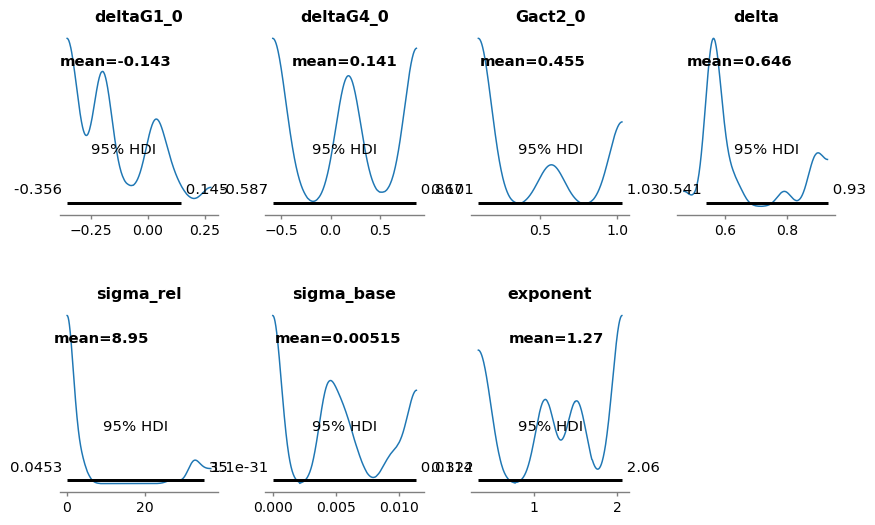

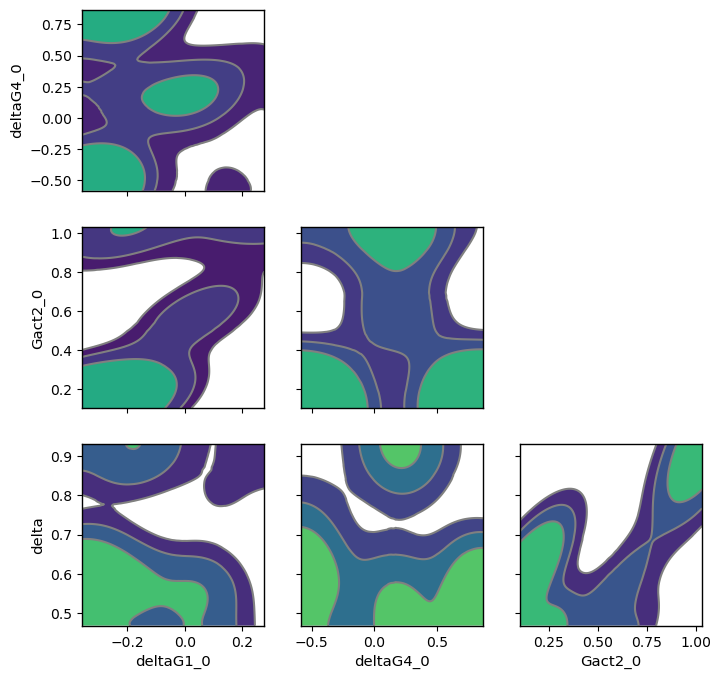

Sampling: [rate]


rate: 0.378


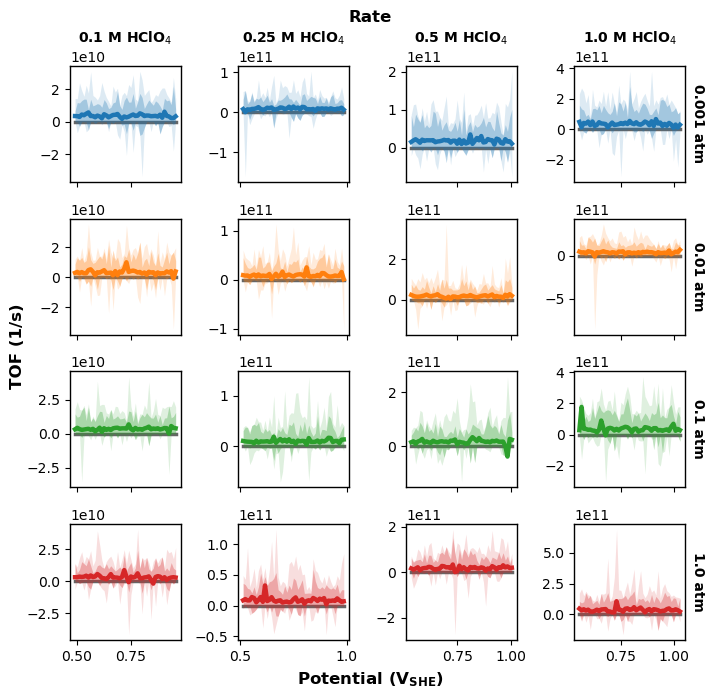

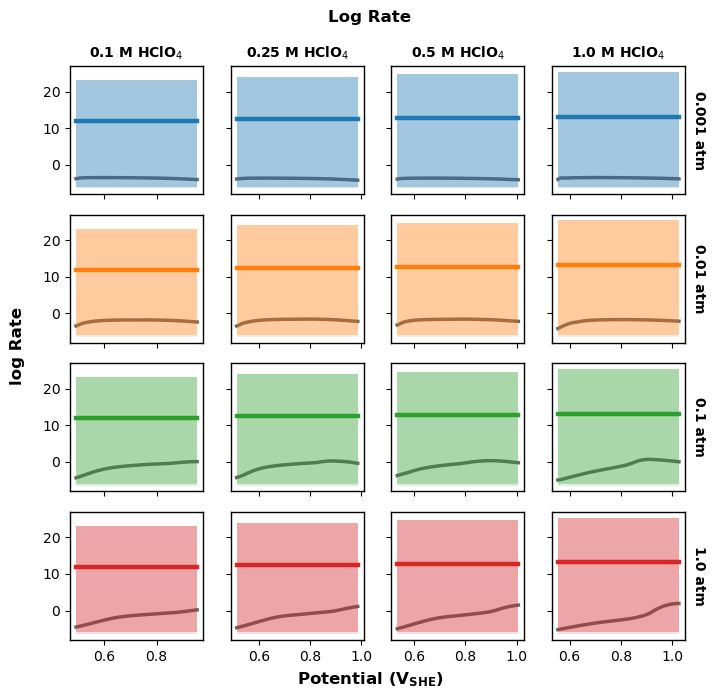

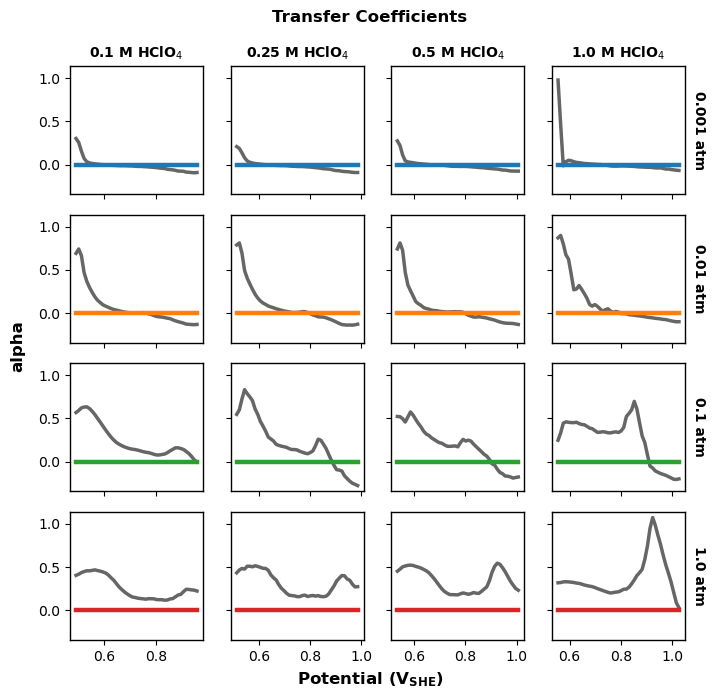

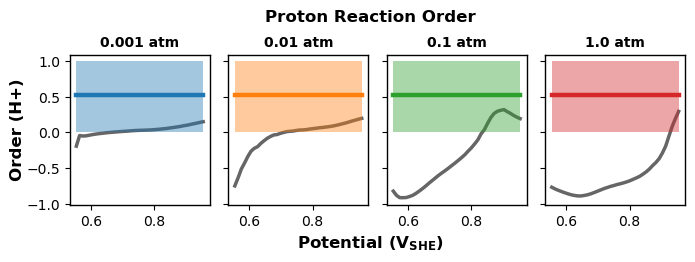

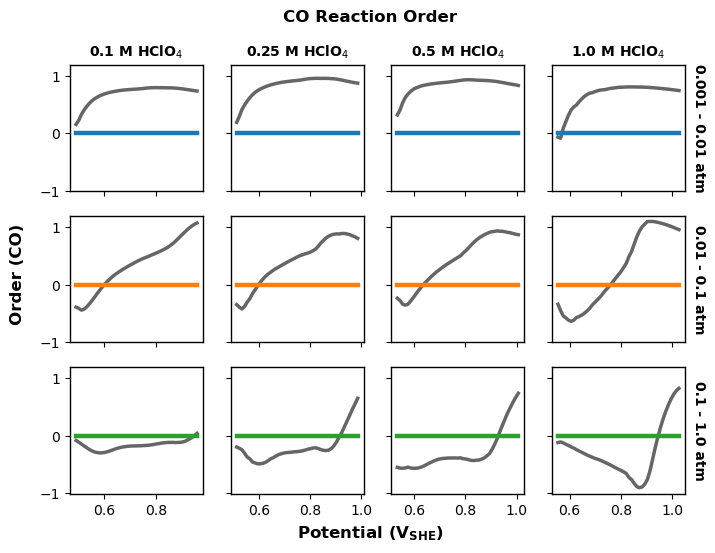

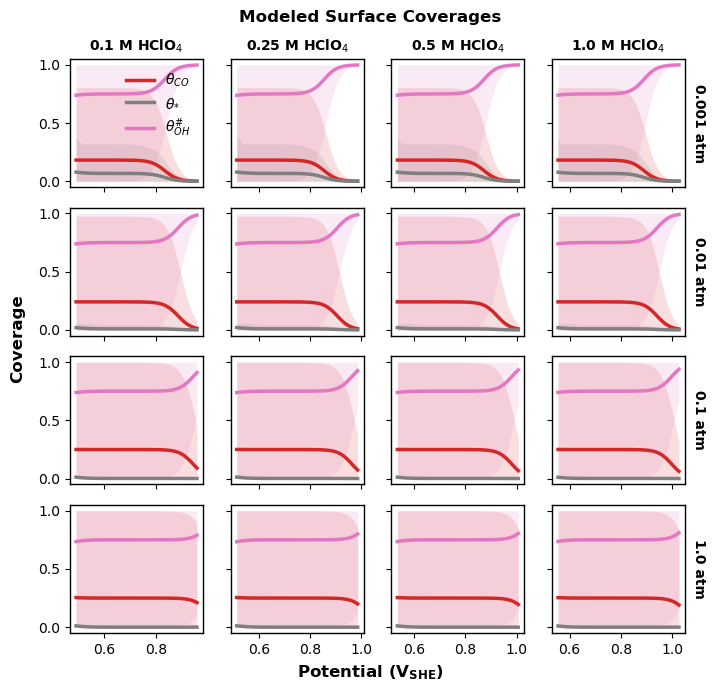

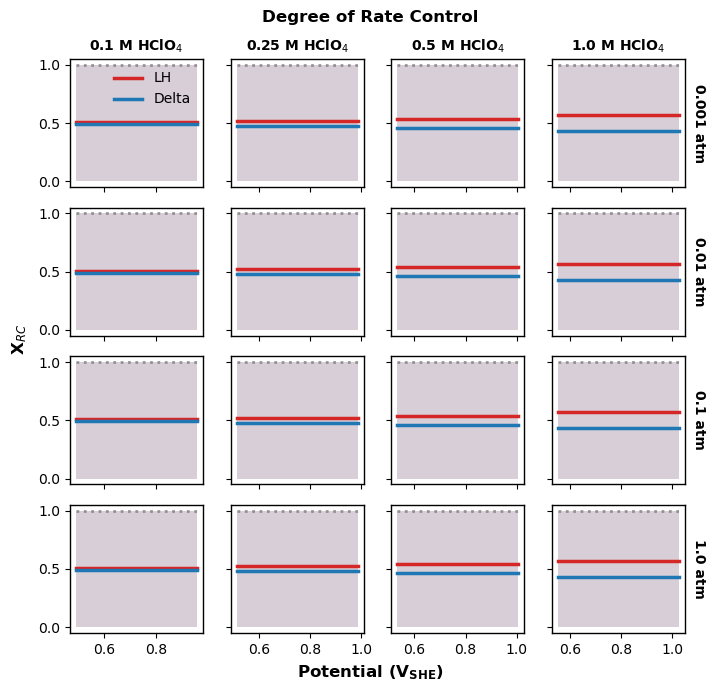

In [5]:
ppc_LH_2 = plot_posteriors(trace_LH_2, LH_2)
plot_model_fits(trace_LH_2, ppc_LH_2); plot_coverages(trace_LH_2)
plot_drc(LH_2, trace_LH_2, perturb_vars=['Gact2_0', 'delta'], perturb_labels=['LH', 'Delta'], 
         var_types={'Gact2_0': 'Gact', 'delta': 'Gact'})

# BF 2 

In [ ]:
with pm.Model() as BF_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH# -> COOH* + # (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    5. H2O + # <-> OH# + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pt = log_K4 - np.log(C_H_in)
    term_OH_Ru = log_K5 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pt = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pt]), axis=0)
    log_theta_Ru = - pt.logsumexp(pt.stack([zeros, term_OH_Ru]), axis=0)
    log_theta_CO = term_CO + log_theta_Pt
    log_theta_OH_Pt = term_OH_Pt + log_theta_Pt
    log_theta_OH_Ru = term_OH_Ru + log_theta_Ru

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pt = pm.Deterministic('theta_OH_Pt', pt.exp(log_theta_OH_Pt))
    theta_OH_Ru = pm.Deterministic('theta_OH_Ru', pt.exp(log_theta_OH_Ru))
    theta_empty_Pt = pm.Deterministic('theta_empty_Pt', pt.exp(log_theta_Pt))
    theta_empty_Ru = pm.Deterministic('theta_empty_Ru', pt.exp(log_theta_Ru))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ru + np.log(Ru_comp)
    rate = observables(log_rate) 

trace_BF_2, loo_BF_2 = fit_and_evaluate(BF_2)

In [ ]:
ppc_BF_2 = plot_posteriors(trace_BF_2, BF_2)
plot_model_fits(trace_BF_2, ppc_BF_2); plot_coverages(trace_BF_2)
plot_drc(BF_2, trace_BF_2, perturb_vars=['Gact2_0'], perturb_labels=['BF'])

# Comparison

In [ ]:
comparison_dict = {
    "LH_2": loo_LH_2,
    "BF_2": loo_BF_2,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()